In [ ]:
# === Install dependencies ===
!pip install yt-dlp pydub tqdm

# === Imports ===
import yt_dlp as youtube_dl
import random
import os
from pydub import AudioSegment
import csv
from tqdm import tqdm

# === Playlist URLs ===
playlists = [
    "https://youtube.com/playlist?list=PL39Vgo021gjfHis9mCiE7XOApWaMlUxXY",
    "https://youtube.com/playlist?list=PLLvbESs96tJiTM1bbT5bPm5VWU5WNuxyV"
]

# === Step 1: Scrape all video URLs ===
all_videos = []

ydl_opts = {
    'ignoreerrors': True,
    'quiet': True,
    'extract_flat': True,  # only metadata
}

for pl in playlists:
    with youtube_dl.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(pl, download=False)
        if info and 'entries' in info:
            for video in info['entries']:
                if video and 'id' in video:
                    all_videos.append("https://www.youtube.com/watch?v=" + video['id'])

print(f"Total videos scraped: {len(all_videos)}")

# === Step 2: Randomly select 100 songs ===
random.seed(42)
selected = random.sample(all_videos, min(100, len(all_videos)))
print(f"Selected {len(selected)} songs")

# === Step 3: Create directories ===
os.makedirs("full", exist_ok=True)
os.makedirs("clipped_songs", exist_ok=True)

# === Step 4: Download & clip audio ===
ydl_opts_audio = {
    'format': 'bestaudio/best',
    'postprocessors': [{
        'key': 'FFmpegExtractAudio',
        'preferredcodec': 'wav',
        'preferredquality': '192',
    }],
    'outtmpl': 'full/%(id)s.%(ext)s',
    'quiet': True,
}

metadata = []

for i, url in enumerate(tqdm(selected, desc="Downloading and clipping"), start=1):
    try:
        with youtube_dl.YoutubeDL(ydl_opts_audio) as ydl:
            info = ydl.extract_info(url, download=True)
            vid_id = info['id']

        audio = AudioSegment.from_wav(f"full/{vid_id}.wav")
        clip = audio[:20 * 1000]  # first 20 seconds

        filename = f"clipped_songs/song_{i:03d}.wav"
        clip.export(filename, format="wav")

        metadata.append([filename, url])
    except Exception as e:
        print(f"Error downloading {url}: {e}")

# === Step 5: Save metadata CSV ===
with open("dataset_metadata.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["file", "original_url"])
    writer.writerows(metadata)

print("Dataset creation complete! Files are in 'clipped_songs/' and metadata saved in 'dataset_metadata.csv'.")


Total videos scraped: 426
Selected 100 songs


ERROR: [youtube] iyiX0cs5swM: This video contains content from SBS(Seoul Broadcasting System), who has blocked it on copyright grounds

Error downloading https://www.youtube.com/watch?v=iyiX0cs5swM: ERROR: [youtube] iyiX0cs5swM: This video contains content from SBS(Seoul Broadcasting System), who has blocked it on copyright grounds


ERROR: [youtube] G6tW8eKUR1E: This video contains content from CJ ENM Co., Ltd., who has blocked it on copyright grounds

Error downloading https://www.youtube.com/watch?v=G6tW8eKUR1E: ERROR: [youtube] G6tW8eKUR1E: This video contains content from CJ ENM Co., Ltd., who has blocked it on copyright grounds


...

ERROR: unable to download video data: HTTP Error 403: Forbidden

Error downloading https://www.youtube.com/watch?v=E1Y3RD3Vt7I: ERROR: unable to download video data: HTTP Error 403: Forbidden


ERROR: [youtube] zwvUnK-agb4: This video is private. If the owner of this video has granted you access, please sign in. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies

Error downloading https://www.youtube.com/watch?v=zwvUnK-agb4: ERROR: [youtube] zwvUnK-agb4: This video is private. If the owner of this video has granted you access, please sign in. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


Dataset creation complete! Files are in 'clipped_songs/' and metadata saved in 'dataset_metadata.csv'.


In [ ]:
from pydub import AudioSegment
import glob

for file in glob.glob("songs/*.wav"):
    audio = AudioSegment.from_file(file)
    clip = audio[:30*1000]  # first 30 seconds
    clip.export(file, format="wav")
    print(f"Clipped {file}")


In [ ]:

!pip install librosa tensorflow scikit-learn umap-learn matplotlib seaborn

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

audio_dir = "clipped_songs/"
files = sorted([os.path.join(audio_dir, f) for f in os.listdir(audio_dir) if f.endswith(".wav")])
print(f"Found {len(files)} audio files.")

def extract_features(file, n_mfcc=20):
    y, sr = librosa.load(file, sr=22050)

    # Skip very short or silent audio
    if len(y) < sr * 2:
        return None

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = np.nan_to_num(mfcc)  # remove NaN/Inf safely
    return np.mean(mfcc.T, axis=0)



Found 94 audio files.


In [ ]:
# VAE
import tensorflow as tf
from tensorflow.keras import layers, Model

latent_dim = 10
input_dim = X.shape[1]

# Sampling function
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

class VAE(Model):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        # Encoder
        self.encoder_dense1 = layers.Dense(64, activation='relu')
        self.encoder_dense2 = layers.Dense(32, activation='relu')
        self.z_mean_layer = layers.Dense(latent_dim)
        self.z_log_var_layer = layers.Dense(latent_dim)
        # Decoder
        self.decoder_dense1 = layers.Dense(32, activation='relu')
        self.decoder_dense2 = layers.Dense(64, activation='relu')
        self.decoder_out = layers.Dense(input_dim)

    def call(self, inputs):
        h = self.encoder_dense1(inputs)
        h = self.encoder_dense2(h)
        z_mean = self.z_mean_layer(h)
        z_log_var = self.z_log_var_layer(h)
        z = sampling([z_mean, z_log_var])
        h_dec = self.decoder_dense1(z)
        h_dec = self.decoder_dense2(h_dec)
        outputs = self.decoder_out(h_dec)

        reconstruction_loss = tf.reduce_mean(tf.keras.losses.mse(inputs, outputs))
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        self.add_loss(reconstruction_loss + kl_loss)
        return outputs

vae = VAE(input_dim=input_dim, latent_dim=latent_dim)
vae.compile(optimizer='adam')

vae.fit(X, X, epochs=100, batch_size=16, verbose=1)


encoder_input = tf.keras.Input(shape=(input_dim,))
h1 = vae.encoder_dense1(encoder_input)
h2 = vae.encoder_dense2(h1)
z_mean = vae.z_mean_layer(h2)
encoder = Model(encoder_input, z_mean)
latent_features = encoder.predict(X)
print("Latent features shape:", latent_features.shape)


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 574907136.0000
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 167929.3750
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 19738.7793 
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7995.3071
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 8425.7842
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7338.8877 
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 6819.3589
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6978.3042
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 6398.8154
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6731.4893
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6767.6553
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 5324.0215
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5281.7134 
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4735.9683
Epoch 15/100
6/6 ━━━━━━━━━━━━━━━

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Latent features shape: (94, 10)


In [ ]:
import numpy as np

#NaNs
print("Any NaNs in latent features?", np.isnan(latent_features).any())

non_nan_idx = ~np.isnan(latent_features).any(axis=1)
latent_features_clean = latent_features[non_nan_idx]

files_clean = np.array(files)[non_nan_idx]
print(f"Removed {len(files) - len(files_clean)} songs with NaNs. Remaining: {len(files_clean)}")


Any NaNs in latent features? False
Removed 0 songs with NaNs. Remaining: 94


In [ ]:
print("Latent clean shape:", latent_features_clean.shape)

if latent_features_clean.shape[0] < 2:
    raise ValueError("Not enough samples after cleaning!")


Latent clean shape: (94, 10)


In [ ]:
from sklearn.cluster import KMeans

n_clusters = 5

kmeans_vae = KMeans(n_clusters=n_clusters, random_state=42)
labels_vae = kmeans_vae.fit_predict(latent_features_clean)

print("KMeans on VAE done")


KMeans on VAE done


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X[non_nan_idx])

kmeans_pca = KMeans(n_clusters=n_clusters, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

print("PCA baseline done")


PCA baseline done


In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

print("===== VAE FEATURES =====")
print("Silhouette Score:", silhouette_score(latent_features_clean, labels_vae))
print("Calinski-Harabasz Index:", calinski_harabasz_score(latent_features_clean, labels_vae))

print("\n===== PCA FEATURES =====")
print("Silhouette Score:", silhouette_score(X_pca, labels_pca))
print("Calinski-Harabasz Index:", calinski_harabasz_score(X_pca, labels_pca))


===== VAE FEATURES =====
Silhouette Score: 0.25969025
Calinski-Harabasz Index: 39.32802

===== PCA FEATURES =====
Silhouette Score: 0.20775531
Calinski-Harabasz Index: 61.88833


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


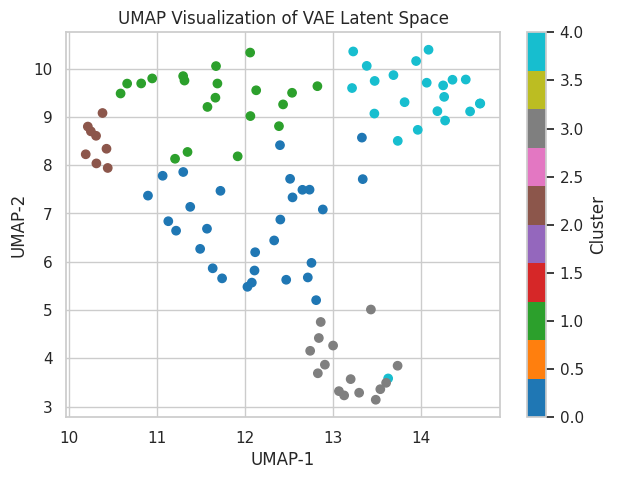

In [ ]:
import umap
import matplotlib.pyplot as plt

umap_embed = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
).fit_transform(latent_features_clean)

plt.figure(figsize=(5,4))
plt.scatter(umap_embed[:,0], umap_embed[:,1], c=labels_vae, cmap="tab10")
plt.colorbar(label="Cluster")
plt.title("UMAP Visualization of VAE Latent Space")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


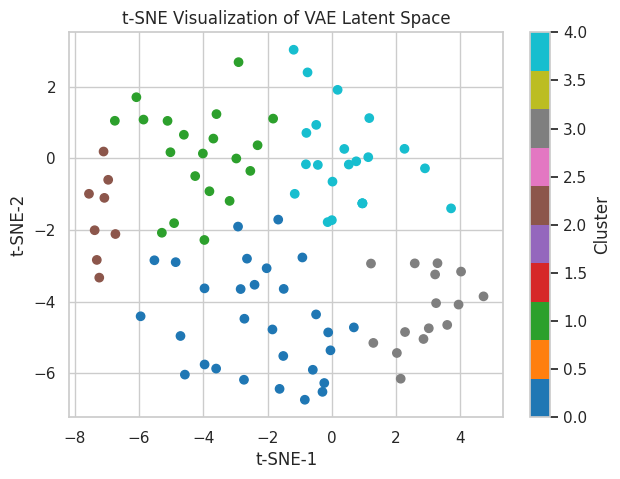

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(latent_features_clean)

plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_vae, cmap="tab10")
plt.colorbar(label="Cluster")
plt.title("t-SNE Visualization of VAE Latent Space")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.show()


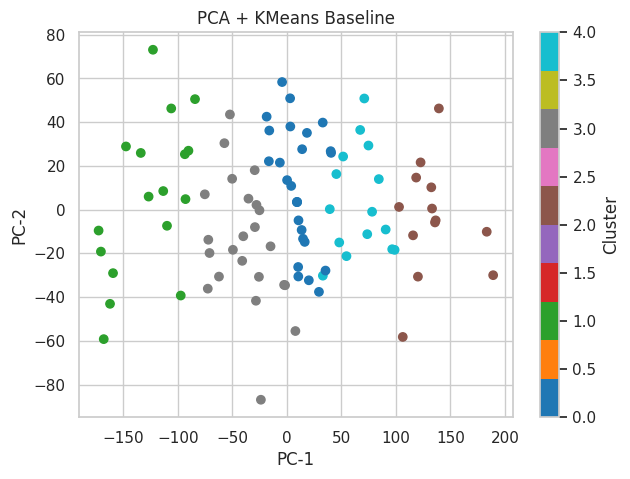

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca, cmap="tab10")
plt.colorbar(label="Cluster")
plt.title("PCA + KMeans Baseline")
plt.xlabel("PC-1")
plt.ylabel("PC-2")
plt.show()


**VAE Training Loss Curve**

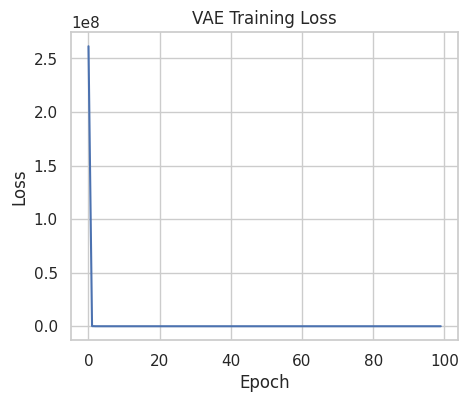

In [ ]:
plt.figure(figsize=(5,4))
plt.plot(vae.history.history['loss'])
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


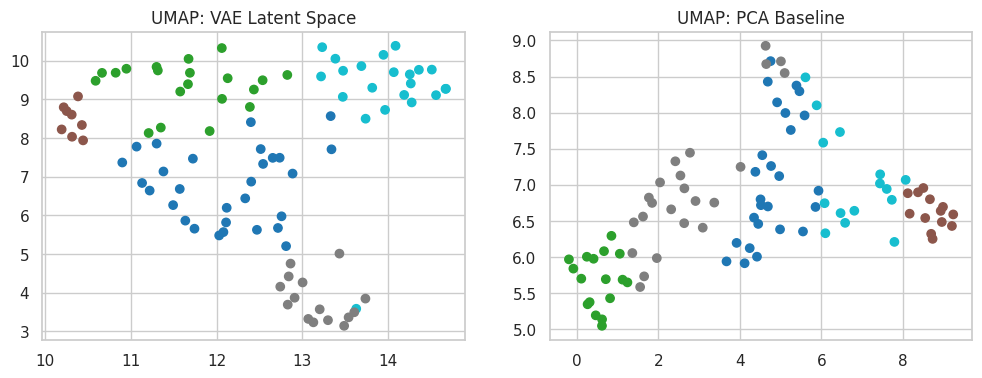

In [ ]:
# UMAP for PCA features
umap_pca = umap.UMAP(random_state=42).fit_transform(X_pca)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(umap_embed[:,0], umap_embed[:,1], c=labels_vae, cmap="tab10")
plt.title("UMAP: VAE Latent Space")

plt.subplot(1,2,2)
plt.scatter(umap_pca[:,0], umap_pca[:,1], c=labels_pca, cmap="tab10")
plt.title("UMAP: PCA Baseline")

plt.show()


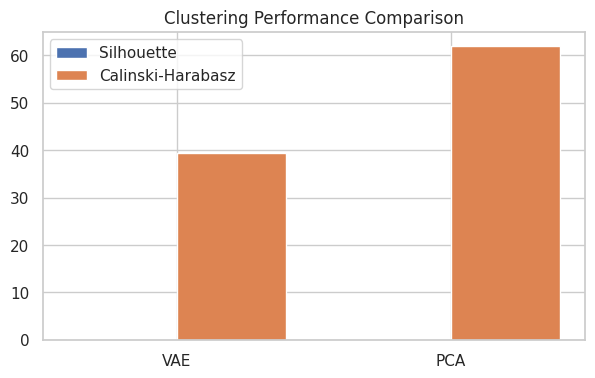

In [ ]:
#Metric Comparison
methods = ["VAE", "PCA"]
sil_scores = [
    silhouette_score(latent_features_clean, labels_vae),
    silhouette_score(X_pca, labels_pca)
]
ch_scores = [
    calinski_harabasz_score(latent_features_clean, labels_vae),
    calinski_harabasz_score(X_pca, labels_pca)
]

x = np.arange(len(methods))

plt.figure(figsize=(7,4))
plt.bar(x-0.2, sil_scores, 0.4, label="Silhouette")
plt.bar(x+0.2, ch_scores, 0.4, label="Calinski-Harabasz")
plt.xticks(x, methods)
plt.legend()
plt.title("Clustering Performance Comparison")
plt.show()


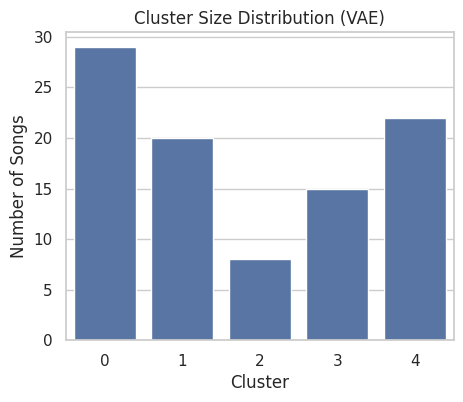

In [ ]:
#Cluster Size
plt.figure(figsize=(5,4))
sns.countplot(x=labels_vae)
plt.title("Cluster Size Distribution (VAE)")
plt.xlabel("Cluster")
plt.ylabel("Number of Songs")
plt.show()


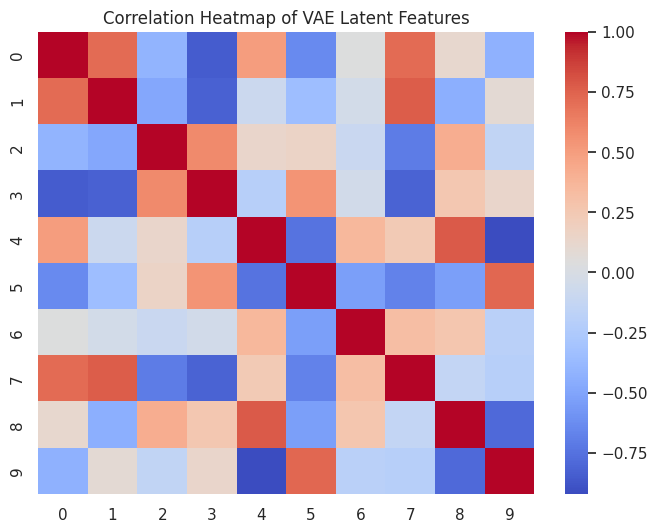

In [ ]:
#Latent Feature Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    np.corrcoef(latent_features_clean.T),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of VAE Latent Features")
plt.show()
